# Sleep Case Study

In [8]:
# Case study source: https://github.com/WillKoehrsen/ai-projects/blob/master/bayesian_inference/bayes_rule_applied.ipynb 

import numpy as np
import pandas as pd
from IPython.core.pylabtools import figsize


import matplotlib.pyplot as plt
%matplotlib inline

figsize(16, 6)

In [4]:
# Data formatted in different notebook
sleep_data = pd.read_csv('sleep_data.csv')

In [5]:
# labels for plotting
sleep_labels = ['9:00', '9:30', '10:00', '10:30', '11:00', '11:30', '12:00']

In [6]:
# Sleep data

Text(0.5, 1.0, 'Falling Asleep Data')

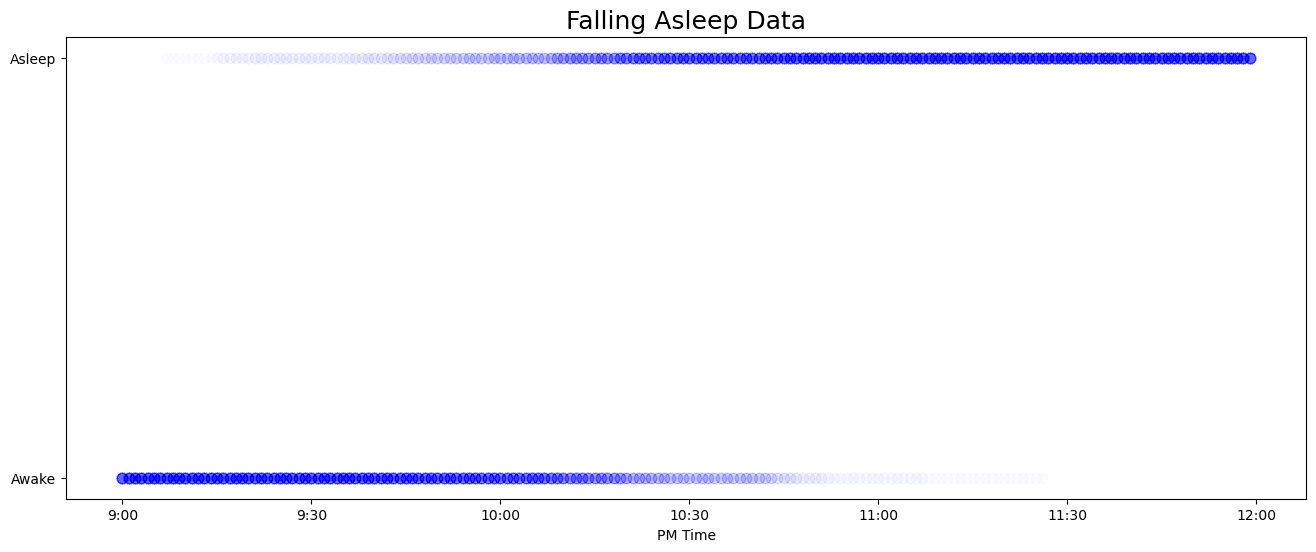

In [9]:
plt.scatter(sleep_data['time_offset'], sleep_data['indicator'], s=60, alpha=0.01, facecolor='b', edgecolors='b')
plt.yticks([0,1], ['Awake', 'Asleep'])
plt.xticks([-60, -30, 0, 30, 60, 90, 120], sleep_labels)
plt.xlabel('PM Time')
plt.title('Falling Asleep Data', size = 18)

In [10]:
sleep_data.head()

,Unnamed: 0,indicator,time_offset
0,2017-12-01 21:00:00,0,-60
1,2017-12-01 21:01:00,0,-59
2,2017-12-01 21:02:00,0,-58
3,2017-12-01 21:03:00,0,-57
4,2017-12-01 21:04:00,0,-56


In [11]:
# sorting values by time offset
sleep_data.sort_values('time_offset', inplace=True)

# Time is the time offset
time = np.array(sleep_data.loc[:, 'time_offset'])

# Observations are the indicator
obs_sleep = np.array(sleep_data.loc[:, 'indicator'])

In [12]:
sleep_data.head()

,Unnamed: 0,indicator,time_offset
0,2017-12-01 21:00:00,0,-60
1620,2017-12-10 21:00:00,0,-60
7740,2018-01-13 21:00:00,0,-60
1980,2017-12-12 21:00:00,0,-60
4140,2017-12-24 21:00:00,0,-60


In [13]:
sleep_data.tail()

,Unnamed: 0,indicator,time_offset
8639,2018-01-17 23:59:00,1,119
1799,2017-12-10 23:59:00,1,119
10799,2018-01-29 23:59:00,1,119
11339,2018-02-01 23:59:00,1,119
8459,2018-01-16 23:59:00,1,119


In [14]:
time

array([-60, -60, -60, ..., 119, 119, 119], shape=(11340,))

In [15]:
obs_sleep

array([0, 0, 0, ..., 1, 1, 1], shape=(11340,))

In [16]:
obs_sleep.shape

(11340,)

In [17]:
obs_sleep[5260:6275]

array([1, 0, 1, ..., 0, 1, 1], shape=(1015,))

In [18]:
sleep_data.loc[sleep_data['time_offset'] == 0]

,Unnamed: 0,indicator,time_offset
6540,2018-01-06 22:00:00,0,0
4380,2017-12-25 22:00:00,0,0
3660,2017-12-21 22:00:00,0,0
9240,2018-01-21 22:00:00,0,0
9600,2018-01-23 22:00:00,0,0
...,...,...,...
10320,2018-01-27 22:00:00,0,0
1140,2017-12-07 22:00:00,0,0
8880,2018-01-19 22:00:00,0,0
7080,2018-01-09 22:00:00,0,0


In [19]:
sleep_data.loc[sleep_data['time_offset'] == 1]

,Unnamed: 0,indicator,time_offset
9241,2018-01-21 22:01:00,0,1
10681,2018-01-29 22:01:00,1,1
4741,2017-12-27 22:01:00,1,1
2581,2017-12-15 22:01:00,0,1
3301,2017-12-19 22:01:00,1,1
...,...,...,...
4921,2017-12-28 22:01:00,0,1
6541,2018-01-06 22:01:00,0,1
9601,2018-01-23 22:01:00,0,1
10141,2018-01-26 22:01:00,0,1


## Calculating Probability at a Particular Time

In [34]:
time_offset = 15

In [36]:
awake_vals = sleep_data.loc[(sleep_data['time_offset'] == time_offset) & (sleep_data['indicator'] == 0)]

sleep_vals = sleep_data.loc[(sleep_data['time_offset'] == time_offset) & (sleep_data['indicator'] == 1)]

In [25]:
# sleep_vals
print(len(sleep_vals))

31


In [26]:
# awake_vals
print(len(awake_vals))

32


In [37]:
prob_sleep_at_offset = len(sleep_vals) / (len(sleep_vals) + len(awake_vals)) 
print(prob_sleep_at_offset)

0.49206349206349204


## Calculating the Prior